# Random Forest — Predicting Popularity

**Target**: `Popularity` (integer, range −65 to 100)  
**Split**: 80% train / 10% val / 10% test  
**Metric**: RMSE and R²

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

In [2]:
df = pd.read_parquet('puzzles_features.parquet')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (1000000, 90)


,Rating,RatingDeviation,Popularity,NbPlays,num_moves,num_openings,num_themes,has_mate,total_material,material_balance,is_endgame,is_check,legal_move_count,white_hanging,black_hanging,first_move_is_capture,first_move_is_check,first_move_is_quiet,first_move_is_sacrifice,has_underpromotion,queensideAttack,morphysMate,queenEndgame,mateIn4,oneMove,mateIn2,triangleMate,pin,long,defensiveMove,clearance,discoveredAttack,vukovicMate,mate,knightEndgame,underPromotion,dovetailMate,superGM,hangingPiece,promotion,...,opening,attackingF2F7,doubleCheck,mateIn1,pillsburysMate,smotheredMate,cornerMate,capturingDefender,advancedPawn,advantage,zugzwang,blindSwineMate,fork,discoveredCheck,endgame,rookEndgame,xRayAttack,exposedKing,veryLong,anastasiaMate,balestraMate,quietMove,bishopEndgame,interference,bodenMate,killBoxMate,master,queenRookEndgame,skewer,operaMate,masterVsMaster,hookMate,castling,doubleBishopMate,short,crushing,equality,kingsideAttack,sacrifice,backRankMate
0,1344,76,90,1728,4,2,5,False,7000,0,0,0,41,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0
1,1526,76,96,22662,6,0,5,False,1400,0,1,0,18,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,2213,75,97,1240,6,0,5,False,1100,100,1,0,17,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


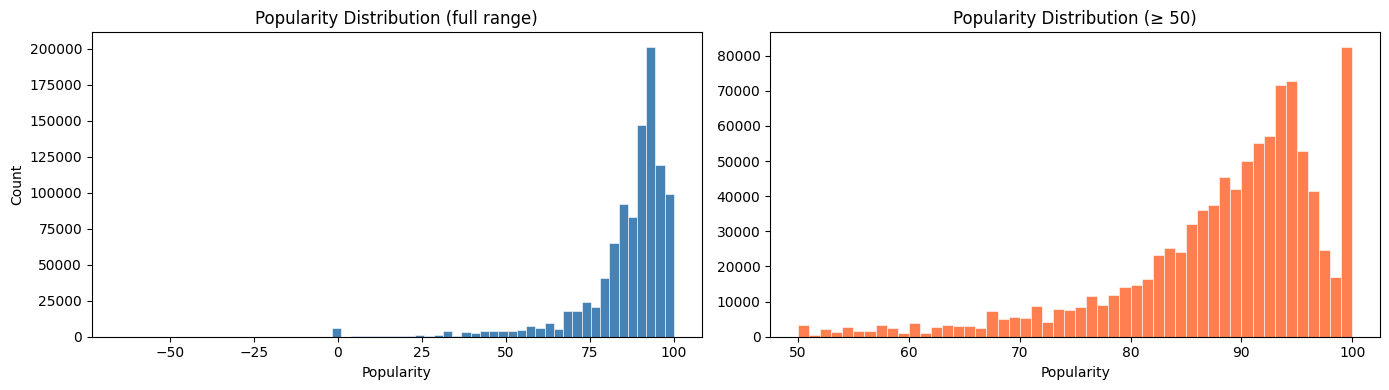

count    1000000.00
mean          86.11
std           14.21
min          -65.00
25%           83.00
50%           90.00
75%           94.00
max          100.00
Name: Popularity, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Popularity'], bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Popularity Distribution (full range)')
axes[0].set_xlabel('Popularity')
axes[0].set_ylabel('Count')

axes[1].hist(df.loc[df['Popularity'] >= 50, 'Popularity'], bins=50, color='coral', edgecolor='white', linewidth=0.4)
axes[1].set_title('Popularity Distribution (≥ 50)')
axes[1].set_xlabel('Popularity')

plt.tight_layout()
plt.show()

print(df['Popularity'].describe().round(2))

In [4]:
DROP_COLS = ['Popularity']

X = df.drop(columns=DROP_COLS)
y = df['Popularity'].astype(float)

print(f'Features: {X.shape[1]}')
print(f'Samples:  {X.shape[0]}')

Features: 89
Samples:  1000000


In [5]:
# Train test split:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED)

print(f'Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')

Train: 800,000  |  Val: 100,000  |  Test: 100,000


In [6]:
X_sub, _, y_sub, _ = train_test_split(X_train, y_train, train_size=0.2, random_state=SEED)

rf_base = RandomForestRegressor(
    n_estimators=100,
    n_jobs=-1,
    random_state=SEED
)
rf_base.fit(X_sub, y_sub)

y_val_pred_base = rf_base.predict(X_val)
rmse_base = np.sqrt(mean_squared_error(y_val, y_val_pred_base))
mae_base  = mean_absolute_error(y_val, y_val_pred_base)
r2_base   = r2_score(y_val, y_val_pred_base)

print(f'Baseline (20% subsample, 100 trees)')
print(f'  Val RMSE : {rmse_base:.4f}')
print(f'  Val MAE  : {mae_base:.4f}')
print(f'  Val R²   : {r2_base:.4f}')


Baseline (20% subsample, 100 trees)
  Val RMSE : 10.8987
  Val MAE  : 6.4863
  Val R²   : 0.4156


In [8]:
param_grid = [
    {'max_depth': None, 'min_samples_leaf': 1},
    {'max_depth': None, 'min_samples_leaf': 5},
    {'max_depth': 20,   'min_samples_leaf': 1},
    {'max_depth': 20,   'min_samples_leaf': 5},
    {'max_depth': 15,   'min_samples_leaf': 5},
]

results = []
for params in param_grid:
    rf = RandomForestRegressor(
        n_estimators=100,
        n_jobs=-1,
        random_state=SEED,
        **params
    )
    rf.fit(X_sub, y_sub)  # still using subsample for speed
    preds = rf.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    mae = mean_absolute_error(y_val, preds)
    r2   = r2_score(y_val, preds)
    results.append({**params, 'Val RMSE': round(rmse, 4), 'Val MAE': round(mae, 4), 'Val R²': round(r2, 4)})
    print(f"max_depth={str(params['max_depth']):4s}  min_samples_leaf={params['min_samples_leaf']}  →  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")

results_df = pd.DataFrame(results)
best_params = results_df.loc[results_df['Val RMSE'].idxmin()]
print(f"\nBest params: max_depth={best_params['max_depth']}, min_samples_leaf={best_params['min_samples_leaf']}")

max_depth=None  min_samples_leaf=1  →  RMSE=10.8987  MAE=6.4863  R²=0.4156
max_depth=None  min_samples_leaf=5  →  RMSE=10.7888  MAE=6.4047  R²=0.4273
max_depth=20    min_samples_leaf=1  →  RMSE=10.8308  MAE=6.4249  R²=0.4228
max_depth=20    min_samples_leaf=5  →  RMSE=10.7761  MAE=6.3919  R²=0.4287
max_depth=15    min_samples_leaf=5  →  RMSE=10.7370  MAE=6.3685  R²=0.4328

Best params: max_depth=15.0, min_samples_leaf=5.0


In [9]:
rf_final = RandomForestRegressor(
    n_estimators=300,
    max_depth=int(best_params['max_depth']) if best_params['max_depth'] is not None else None,
    min_samples_leaf=int(best_params['min_samples_leaf']),
    n_jobs=-1,
    random_state=SEED,
    verbose=1
)
rf_final.fit(X_train, y_train)
print('Training complete.')

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:  8.9min


Training complete.


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed: 15.0min finished


In [11]:
y_val_pred  = rf_final.predict(X_val)
y_test_pred = rf_final.predict(X_test)

val_rmse  = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2    = r2_score(y_val, y_val_pred)
val_mae   = mean_absolute_error(y_val, y_val_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2   = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)


print(f'{'':20s}  {'RMSE':>8s}  {'MAE':>8s}  {'R²':>8s}')
print(f"{'Validation':20s}  {val_rmse:>8.4f}  {val_mae:>8.4f}  {val_r2:>8.4f}")
print(f"{'Test':20s}  {test_rmse:>8.4f}  {test_mae:>8.4f}  {test_r2:>8.4f}")

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.7s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    1.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.5s


                          RMSE       MAE        R²
Validation             10.6102    6.2847    0.4461
Test                   10.5364    6.2443    0.4480


[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.8s finished


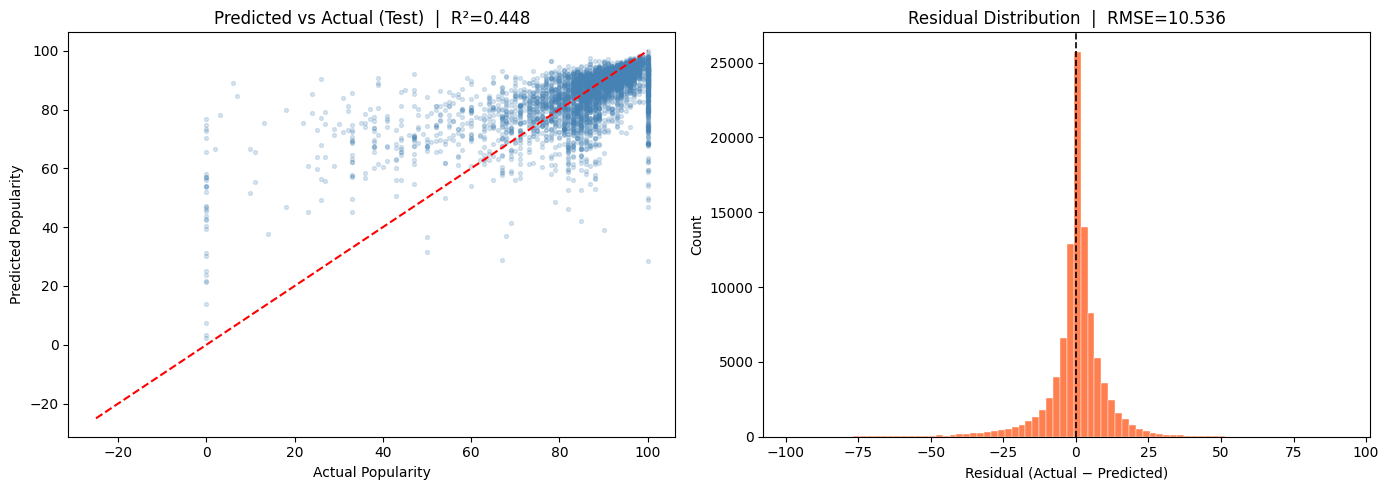

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
sample_idx = np.random.choice(len(y_test), size=5000, replace=False)
axes[0].scatter(y_test.iloc[sample_idx], y_test_pred[sample_idx], alpha=0.2, s=8, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual Popularity')
axes[0].set_ylabel('Predicted Popularity')
axes[0].set_title(f'Predicted vs Actual (Test)  |  R²={test_r2:.3f}')

# Residuals
residuals = y_test.values - y_test_pred
axes[1].hist(residuals, bins=80, color='coral', edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual Distribution  |  RMSE={test_rmse:.3f}')

plt.tight_layout()
plt.show()

In [15]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
dummy_preds = dummy.predict(X_test)

dummy_rmse = np.sqrt(mean_squared_error(y_test, dummy_preds))
dummy_mae = mean_absolute_error(y_test, dummy_preds)
dummy_r2 = r2_score(y_test, dummy_preds)
print(f'Dummy (predict mean)  RMSE={dummy_rmse:.4f}  MAE={dummy_mae:.4f}  R²={dummy_r2:.4f}')

Dummy (predict mean)  RMSE=14.1813  MAE=9.1947  R²=-0.0000


In [16]:
comparison = pd.DataFrame([
    {'Model': 'Dummy (mean baseline)', 'RMSE': dummy_rmse, 'MAE': dummy_mae, 'R²': dummy_r2},
    {'Model': 'Random Forest',         'RMSE': test_rmse,  'MAE': test_mae,  'R²': test_r2},
])
print(comparison.to_string(index=False, float_format='%.4f'))

                Model    RMSE    MAE      R²
Dummy (mean baseline) 14.1813 9.1947 -0.0000
        Random Forest 10.5364 6.2443  0.4480
